# Reto de Vision: Clasificacion de Productos con CNN

## Notebook 3 - Evaluacion analitica y analisis de negocio

### Donde quedamos

En la sesion anterior construimos, compilamos y entrenamos una CNN sobre `Fashion MNIST`, y guardamos el modelo entrenado (`modelo_cnn_fashion.keras`) junto con el historial de entrenamiento (`historial_entrenamiento.json`). No hace falta volver a entrenar nada hoy.

### Objetivos de esta sesion

- Cargar el modelo ya entrenado y su historial, sin repetir el entrenamiento.
- Graficar la evolucion del loss y del accuracy durante el entrenamiento, e interpretar si el modelo aprendio bien o si hay señales de overfitting.
- Evaluar el modelo formalmente sobre el set de prueba.
- Construir una matriz de confusion para ver, categoria por categoria, en donde acierta y en donde falla el modelo.
- Identificar en que categorias se confunde mas el modelo, y discutir el impacto financiero que eso tendria para la empresa de e-commerce, ademas de posibles soluciones.

Este notebook es la Fase 3 del reto: la parte analitica, donde convertimos metricas tecnicas en conclusiones que le sirven al negocio.

## 1. Cargando el modelo, el historial y los datos de prueba

Como este es un notebook nuevo, necesitamos volver a traer los datos de prueba (`X_test`, `y_test`) y aplicarles el mismo preprocesamiento que usamos antes (normalizar y hacer reshape a 4D). No necesitamos `X_train` ni `y_train` porque en esta sesion no vamos a entrenar nada.

Tambien vamos a cargar:

- El modelo ya entrenado, con `keras.models.load_model()`.
- El historial de entrenamiento, que guardamos como un archivo `.json`, con `json.load()`.

Nota: este notebook asume que los archivos `modelo_cnn_fashion.keras` y `historial_entrenamiento.json` que generamos en la sesion anterior estan en la misma carpeta que este notebook.

In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
import json
from sklearn.metrics import confusion_matrix

_, (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

X_test = X_test / 255.0
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1)

class_names = [
    "Playera/Top", "Pantalon", "Sueter", "Vestido", "Abrigo",
    "Sandalia", "Camisa", "Tenis", "Bolso", "Botin"
]

modelo = keras.models.load_model("modelo_cnn_fashion.keras")

with open("historial_entrenamiento.json", "r") as archivo:
    historial = json.load(archivo)

print("Modelo e historial cargados correctamente.")
print("X_test:", X_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Modelo e historial cargados correctamente.
X_test: (10000, 28, 28, 1)


## 2. Evolucion del entrenamiento: graficas de Loss y Accuracy

El diccionario `historial` tiene 4 listas, una por metrica y por conjunto de datos: `loss`, `accuracy` (entrenamiento) y `val_loss`, `val_accuracy` (validacion), con un valor por epoca.

Vamos a graficar dos cosas, una al lado de la otra:

1. La evolucion del `loss` de entrenamiento contra el `loss` de validacion.
2. La evolucion del `accuracy` de entrenamiento contra el `accuracy` de validacion.

### Como interpretar estas graficas

- Si el loss de entrenamiento sigue bajando pero el de validacion deja de bajar (o empieza a subir), es una señal clasica de overfitting: el modelo esta memorizando el set de entrenamiento en vez de aprender patrones que generalicen.
- Si ambas curvas (entrenamiento y validacion) bajan juntas y se estabilizan cerca una de la otra, es una buena señal de que el modelo esta generalizando bien.

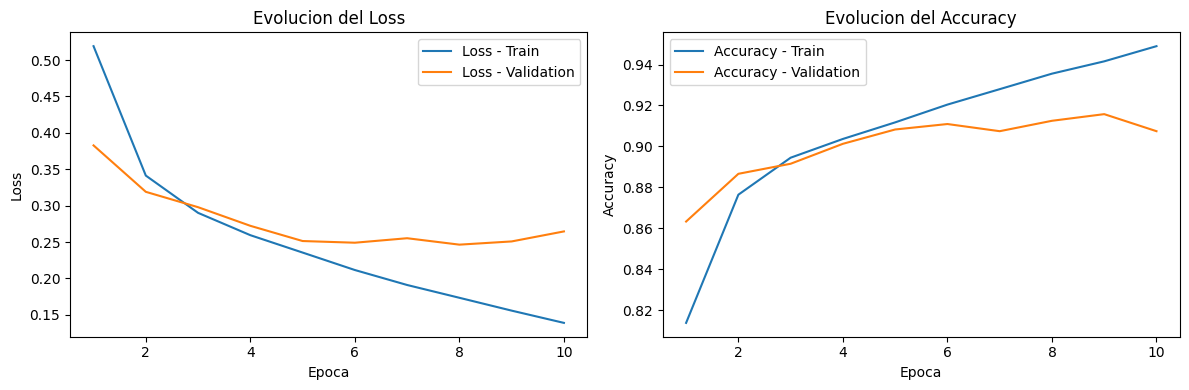

In [5]:
epocas = range(1, len(historial["loss"]) + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epocas, historial["loss"], label="Loss - Train")
plt.plot(epocas, historial["val_loss"], label="Loss - Validation")
plt.xlabel("Epoca")
plt.ylabel("Loss")
plt.title("Evolucion del Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epocas, historial["accuracy"], label="Accuracy - Train")
plt.plot(epocas, historial["val_accuracy"], label="Accuracy - Validation")
plt.xlabel("Epoca")
plt.ylabel("Accuracy")
plt.title("Evolucion del Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

## 3. Evaluacion formal sobre el set de prueba

`history` nos dio el accuracy de validacion epoca por epoca, pero ahora vamos a calcular una metrica final, limpia, usando `model.evaluate()` directamente sobre `X_test` y `y_test`. Esto nos da el loss y el accuracy definitivos del modelo ya entrenado.

In [3]:
test_loss, test_accuracy = modelo.evaluate(X_test, y_test, verbose=0)

print("Loss en el set de prueba: {:.4f}".format(test_loss))
print("Accuracy en el set de prueba: {:.2%}".format(test_accuracy))

Loss en el set de prueba: 0.2691
Accuracy en el set de prueba: 90.60%


## 4. Generando las predicciones

El accuracy general nos dice que tan bien le va al modelo en promedio, pero no nos dice nada sobre en que categorias especificas falla mas. Para eso necesitamos ver, imagen por imagen, cual fue la prediccion del modelo.

### Que vamos a programar

1. Usar `modelo.predict(X_test)` para obtener las probabilidades que el modelo asigna a cada una de las 10 categorias, para cada imagen del set de prueba. El resultado tiene shape `(10000, 10)`.
2. Usar `np.argmax(..., axis=1)` para quedarnos, por cada imagen, con el indice de la categoria con mayor probabilidad. Ese es el vector de predicciones finales, comparable directamente con `y_test`.

In [24]:
probabilidades = modelo.predict(X_test)

np.round(probabilidades[1] * 100)

array([  0.,   0., 100.,   0.,   0.,   0.,   0.,   0.,   0.,   0.],
      dtype=float32)

In [27]:
y_pred = np.argmax(probabilidades, axis=1)

print("Shape de las probabilidades:", probabilidades.shape)
print("Shape de las predicciones finales:", y_pred.shape)
print("Primeras 10 predicciones:", y_pred[:10])
print("Primeras 10 etiquetas reales:", y_test[:10])

Shape de las probabilidades: (10000, 10)
Shape de las predicciones finales: (10000,)
Primeras 10 predicciones: [9 2 1 1 6 1 4 6 5 7]
Primeras 10 etiquetas reales: [9 2 1 1 6 1 4 6 5 7]


## 5. Matriz de confusion

La matriz de confusion es una tabla de 10x10 (una fila y una columna por categoria) donde cada celda `[i, j]` indica cuantas imagenes cuya categoria real es `i` fueron clasificadas por el modelo como `j`. La diagonal principal son los aciertos; todo lo que esta fuera de la diagonal son errores.

### Que vamos a programar

1. Calcular la matriz con `confusion_matrix(y_test, y_pred)` de sklearn.
2. Mostrarla como un heatmap con `matplotlib`, usando `class_names` como etiquetas de filas y columnas, para que sea facil de leer.

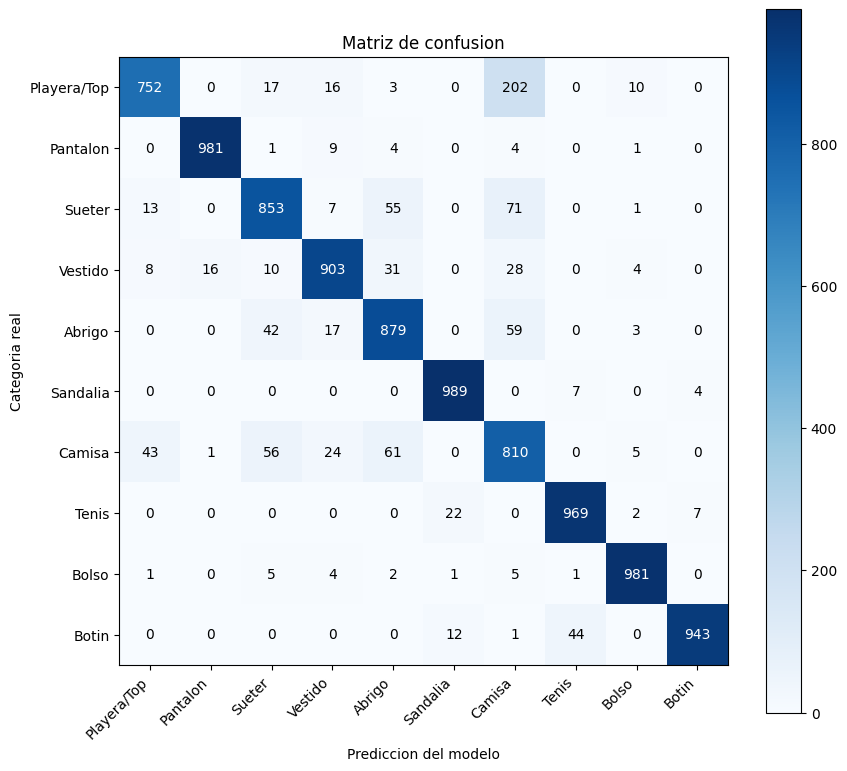

In [33]:
matriz_confusion = confusion_matrix(y_test, y_pred) # Calculamos la confusion matrix comparando las categorías reales con las predicciones del modelo

plt.figure(figsize=(9, 8))
plt.imshow(matriz_confusion, cmap="Blues")
plt.colorbar()
plt.xticks(ticks=range(10), labels=class_names, rotation=45, ha="right")
plt.yticks(ticks=range(10), labels=class_names)
plt.xlabel("Prediccion del modelo")
plt.ylabel("Categoria real")
plt.title("Matriz de confusion")

for i in range(10): # Mostramos el número de ejemplos dentro de cada celda y ajustamos el color del texto según el valor
    for j in range(10):
        plt.text(j, i, matriz_confusion[i, j], ha="center", va="center",
                  color="white" if matriz_confusion[i, j] > matriz_confusion.max() / 2 else "black")

plt.tight_layout()
plt.show()

## 6. Encontrando las confusiones mas grandes

Mirar la matriz completa a simple vista ayuda, pero conviene tambien identificar de forma programatica cuales son los pares de categorias que mas se confunden entre si (los valores mas altos fuera de la diagonal).

### Que vamos a programar

1. Hacer una copia de la matriz de confusion y poner en cero la diagonal principal (los aciertos no nos interesan aca).
2. Recorrer la matriz y guardar, para cada combinacion `(categoria real, categoria predicha)`, la cantidad de errores.
3. Ordenar esa lista de mayor a menor y mostrar los 5 pares que mas se confunden.

In [47]:
matriz_sin_diagonal = matriz_confusion.copy() # Creamos una copia de la confusion matrix para no modificar la original
np.fill_diagonal(matriz_sin_diagonal, 0) # Ponemos en cero la diagonal porque representa las predicciones correctas

confusiones = [] # lista vacía para almacenar las predicciones incorrectas
for i in range(10):
    for j in range(10):
        if matriz_sin_diagonal[i, j] > 0:
            confusiones.append((matriz_sin_diagonal[i, j], class_names[i], class_names[j]))

confusiones.sort(reverse=True) # Ordenamos las confusiones de mayor a menor cantidad

print("Las 5 confusiones mas frecuentes (categoria real -> categoria predicha):")
for cantidad, real, predicha in confusiones[:5]:
    print("{} -> {}: {} imagenes".format(real, predicha, cantidad))

Las 5 confusiones mas frecuentes (categoria real -> categoria predicha):
Playera/Top -> Camisa: 202 imagenes
Sueter -> Camisa: 71 imagenes
Camisa -> Abrigo: 61 imagenes
Abrigo -> Camisa: 59 imagenes
Camisa -> Sueter: 56 imagenes


## 7. Accuracy por categoria

El accuracy general esconde diferencias importantes entre categorias. Vamos a calcular el accuracy especifico de cada una: de todas las imagenes reales de una categoria, que porcentaje clasifico bien el modelo. Esto es simplemente el valor de la diagonal dividido entre la suma de la fila correspondiente.

Ordenamos el resultado de menor a mayor para que las categorias mas problematicas queden primero.

In [53]:
# Calculamos el accuracy de cada categoría dividiendo las predicciones correctas entre el total de imágenes reales de cada categoría
accuracy_por_categoria = matriz_confusion.diagonal() / matriz_confusion.sum(axis=1)

resultados = list(zip(class_names, accuracy_por_categoria)) # Combinamos cada nombre de categoría con su respectivo accuracy
resultados.sort(key=lambda x: x[1]) # Ordenamos las categorías de menor a mayor accuracy

print("Accuracy por categoria (de peor a mejor):")
for categoria, acc in resultados:
    print("{}: {:.2%}".format(categoria, acc))

Accuracy por categoria (de peor a mejor):
Playera/Top: 75.20%
Camisa: 81.00%
Sueter: 85.30%
Abrigo: 87.90%
Vestido: 90.30%
Botin: 94.30%
Tenis: 96.90%
Pantalon: 98.10%
Bolso: 98.10%
Sandalia: 98.90%


## 8. Viendo ejemplos mal clasificados

Los numeros ayudan, pero ver las imagenes reales que el modelo confundio nos da mucha mas intuicion sobre por que se equivoca. Vamos a buscar imagenes donde la prediccion no coincide con la etiqueta real, y mostrar algunas de ellas junto con la categoria real y la categoria predicha.

### Que vamos a programar

1. Usar `np.where(y_pred != y_test)` para obtener los indices de todas las imagenes mal clasificadas.
2. Elegir los primeros 10 indices de esa lista.
3. Mostrarlos en una cuadricula, con un titulo que diga la categoria real y la categoria predicha para cada una.

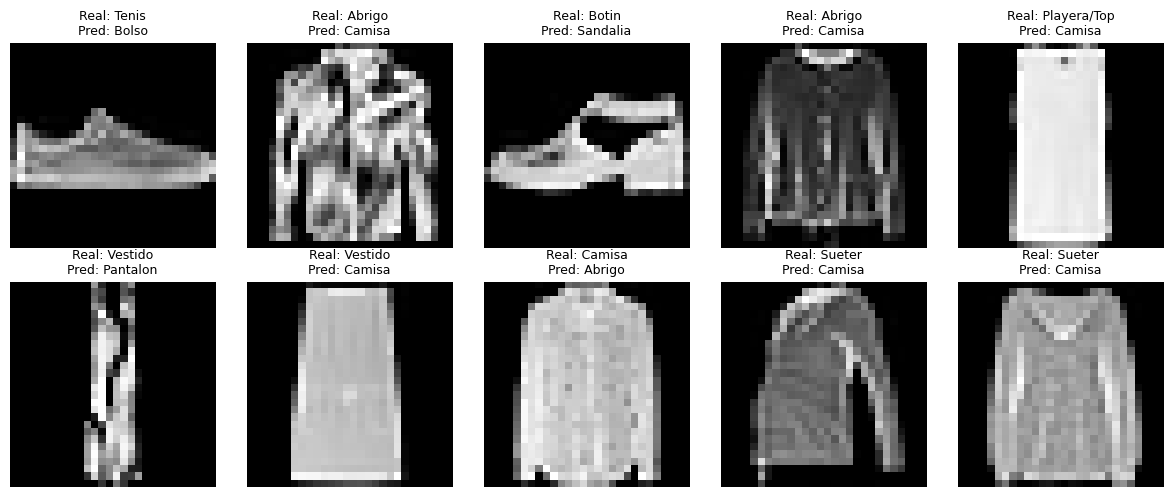

In [61]:
indices_errores = np.where(y_pred != y_test)[0] # Obtenemos los índices de las imágenes donde la predicción es diferente a la categoría real
# seleccionamo el primero elemento ([0]) porque np.where return a tuple

plt.figure(figsize=(12, 5))
for i, idx in enumerate(indices_errores[:10]):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[idx].reshape(28, 28), cmap="gray") # Mostramos la imagen correspondiente al error en escala de grises
    plt.title("Real: {}\nPred: {}".format(class_names[y_test[idx]], class_names[y_pred[idx]]), fontsize=9) # Mostramos la categoría real y la categoría predicha como título
    plt.axis("off")
plt.tight_layout()
plt.show()

Mostramos los primeros 3 errores como pares: la imagen que el modelo clasificó incorrectamente y un ejemplo de una imagen de la categoría que el modelo predijo.

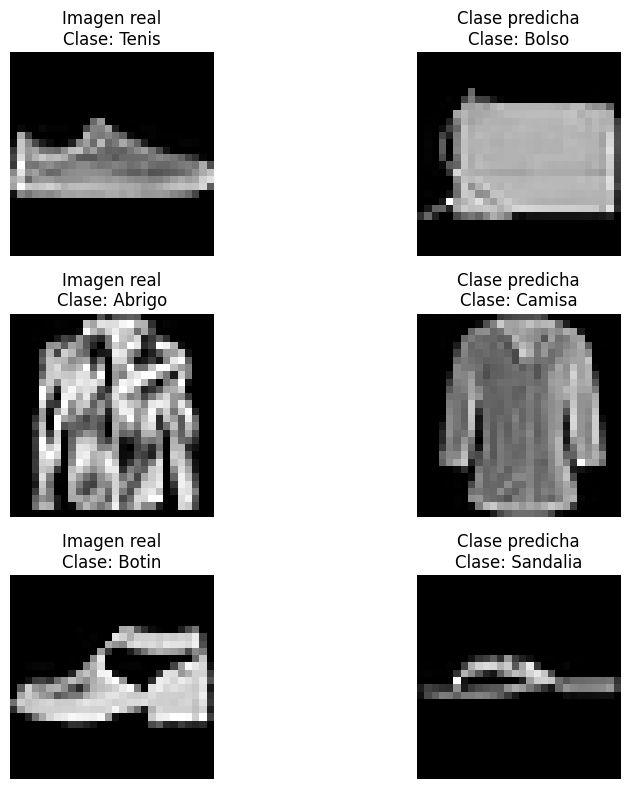

In [63]:
plt.figure(figsize=(10, 8))

for i, idx in enumerate(indices_errores[:3]):  # Recorremos los primeros 3 errores
    real = y_test[idx]  # Obtenemos la categoría real de la imagen
    predicha = y_pred[idx]  # Obtenemos la categoría predicha por el modelo

    # Imagen que el modelo clasificó incorrectamente
    plt.subplot(3, 2, 2 * i + 1)
    plt.imshow(X_test[idx].reshape(28, 28), cmap="gray")
    plt.title("Imagen real\nClase: {}".format(class_names[real]))
    plt.axis("off")

    # Buscamos una imagen que realmente pertenezca a la categoría predicha
    indice_correcto = np.where(y_test == predicha)[0][0]  # Obtenemos el índice de la primera imagen de esa categoría

    plt.subplot(3, 2, 2 * i + 2)  # Creamos una posición para la imagen de comparación
    plt.imshow(X_test[indice_correcto].reshape(28, 28), cmap="gray")  # Mostramos una imagen de la categoría predicha
    plt.title("Clase predicha\nClase: {}".format(class_names[predicha]))  # Mostramos la categoría que predijo el modelo
    plt.axis("off")  # Ocultamos los ejes

plt.tight_layout()
plt.show()

## 9. Identificando predicciones de baja confianza

Ademas de ver si el modelo acerto o no, podemos mirar que tan seguro estaba de su prediccion. Recuerda que `probabilidades` tiene, para cada imagen, una probabilidad por cada una de las 10 categorias (todas suman 1 gracias a `softmax`). El valor mas alto de esas 10 probabilidades es la "confianza" del modelo en su propia prediccion.

Esto es util para el negocio: en vez de confiar ciegamente en el modelo para el 100% de las imagenes, podriamos definir un umbral (por ejemplo 70%) y mandar a revision humana unicamente las imagenes donde el modelo no esta seguro, en vez de revisar todo el catalogo a mano.

### Que vamos a programar

1. Calcular la confianza maxima de cada prediccion con `np.max(probabilidades, axis=1)`.
2. Contar cuantas imagenes del set de prueba quedarian por debajo de un umbral de confianza, por ejemplo 0.70.

In [55]:
confianza = np.max(probabilidades, axis=1)
umbral = 0.70

cantidad_baja_confianza = np.sum(confianza < umbral)
porcentaje_baja_confianza = cantidad_baja_confianza / len(confianza)

print("Imagenes con confianza menor a {:.0%}: {} de {} ({:.2%})".format(
    umbral, cantidad_baja_confianza, len(confianza), porcentaje_baja_confianza
))

Imagenes con confianza menor a 70%: 964 de 10000 (9.64%)


## 10. Pregunta de negocio: interpretando los resultados para la empresa

Ya tenemos toda la evidencia tecnica: la matriz de confusion, las categorias con menor accuracy, los pares que mas se confunden y el porcentaje de predicciones de baja confianza. Ahora toca conectar esto con el negocio de e-commerce de moda.

Discute con tu equipo, apoyandote en los resultados que obtuviste arriba:

1. **Cuales categorias se confunden mas entre si, y por que crees que pasa.** Piensa en como se ven esas prendas en escala de grises y baja resolucion (28x28 pixeles). Por ejemplo, es comun que el modelo confunda prendas de la parte superior del cuerpo entre si (playeras, sueteres, camisas, abrigos), porque a esa resolucion se parecen mucho en silueta.

2. **Impacto financiero de estos errores.** Si una playera se etiqueta como camisa, o un abrigo como sueter, que consecuencias tiene esto para la empresa. Piensa en busquedas de clientes que no encuentran el producto en la categoria correcta, filtros del sitio web que excluyen productos mal etiquetados, costos de logistica si el error afecta el empaquetado o el envio, y el costo de tener que corregir el catalogo manualmente despues.

3. **Como lo solucionarias.** Algunas ideas para investigar y discutir:
   - Usar imagenes de mayor resolucion y a color en vez de 28x28 en escala de grises (Fashion MNIST es un dataset simplificado para aprender, no representa fotos reales de un catalogo).
   - Conseguir mas datos de entrenamiento especificamente para las categorias con menor accuracy.
   - Aplicar Data Augmentation (rotaciones, zoom, cambios de brillo) para que el modelo generalice mejor.
   - Usar Transfer Learning con arquitecturas mas grandes y ya entrenadas (como ResNet o EfficientNet) en vez de entrenar una CNN pequeña desde cero.
   - Definir un flujo de "humano en el circuito" (human-in-the-loop): las predicciones con confianza por debajo de un umbral se mandan a revision manual en vez de publicarse directo, como calculamos en la seccion anterior.

No hay una unica respuesta correcta: el objetivo es que sepas leer las metricas de un modelo de clasificacion de imagenes y traducirlas en una recomendacion concreta para el negocio.

## Resumen del reto completo

A lo largo de estas tres sesiones:

- **Notebook 1**: entendimos que hace una convolucion y un max pooling programandolos a mano, y dejamos `Fashion MNIST` normalizado y con la forma correcta para una CNN.
- **Notebook 2**: construimos una arquitectura CNN completa (`Conv2D`, `MaxPooling2D`, `Flatten`, `Dense`), la compilamos y la entrenamos, guardando el modelo y el historial de entrenamiento.
- **Notebook 3**: evaluamos el modelo de forma rigurosa, identificamos sus puntos debiles con una matriz de confusion, y conectamos esos resultados tecnicos con decisiones de negocio para la empresa de e-commerce de moda.

Este flujo completo (preparar datos, construir y entrenar un modelo, evaluarlo a fondo y traducir los resultados a decisiones de negocio) es el mismo que vas a repetir, con distintas arquitecturas y datasets, en cualquier proyecto real de ciencia de datos.